# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt # importar librerías

In [55]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [56]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [57]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [58]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [59]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [60]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [61]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [62]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [63]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [64]:
print(usage.isna().sum())
print(usage.isna().mean())# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En la tabla de users hay valores nulos en las columnas city (469) en proporción 11.73% y en churn_date(3534) en proporción 88.35%.   
- En la tabla de usage tenemos valores nulos en las columnas date(50) en porporción 0.13%, duration(22076) en porporción 55% y lenght(17896) en porporción 44.7%
  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- **Users**: La columna city está en el rango de 5-30% por lo que hay que investigar para imputar o dejar como nulos. En la columna churn_date el valor entra en el rango de 80-90% de nulos por lo que se ignoraría o eliminaría. En este caso no se elimina debido a que los valores nulos tienen sentido ya que indican que el usuario sigue activo en su plan.
- **Usage**: Para la columna date, tiene un valor menor al 5% por lo que se debe de imputar o dejar como nulo ya que a una fecha no se le puede sacar promedio a menos que se quiera tomar el año y sacar promedio o mediana e imputarlo así. Para las columnas de duration y lenght es normal que tengan esas proporciones mayores de 30% y menores de 80% debido a que ambas se relacionan, es decir, cuando hay llamadas hay duración pero no longitud y cuando hay mensajes hay longitud del texto pero no duración en segundos; aquí los nulos también tienen sentido al darnos información al igual que en la columna churn_date de la tabla Users.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [65]:
users.describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene una desviación estándar amplia (lejos de la unidad) por lo que tiene un sesgo. No obstante no hay problema ya que el user_id es un valor asignado para el cliente pero no nos funciona para hacer cálculos o análisis. Solo influiría si el valor de user_id se repite.
- La columna `age` tiene un valos mínimo de -999 por lo que indica que hubo algún error en el sistema o simplemente no se tiene ese dato y se coloco el -999. Ese valor no es probable debido a que no hay persona que tenga esa cantidad de años en negativo. Al existir ese dato entonces el promedio se ve afectado al igual que la desviación estándar (std).

In [66]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`el id es el número de folio de cada evento (llamada o mensaje) mienras que el user_id es el número de cliente que realizó dicha llamada o mensaje. Por su desviación estándar podemos observar que los valores no se centran en un solo valor pero eso es normal ya que no tiene sentido sacar promedio de ambas columnas.
- Las columnas duration y lenght sí nos pueden dar información como cuánto dura en promedio una llamada o qué longitud en promedio tiene un mensaje. La std de duration es baja por lo que es confiable en que haya un valor promedio confiable mientras que la std del mensaje está un poco elevada por lo que podría darnos señal de algunos valores atípicos como que algunas personas enviaron mensaje mucho más largos de lo normal afectando los valores estadísticos. 

In [67]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` 7 ciudades únicas en las que Bogotá es la que más se repite (808 veces) con la función .describe(). Cuando se usa value_counts() podemos observar que hay valores inválidos "?" 65 veces con el básico y 31 veces con el plan premium. 
- La columna `plan` muestra solo 2 tipos de planes en el que el Basico es el más contratado (2595 veces aparece)

In [68]:
# explorar columna categórica de usage
usage['type'].describe() 
usage.value_counts()# completa el código

id     user_id  type  date                           duration  length
1415   10399    text  2024-01-07 09:33:51.260781519  120.00    65.0      1
1825   12936    text  2024-01-09 06:05:28.868221705  120.00    40.0      1
38955  12961    text  2024-06-25 06:30:36.585914646  120.00    47.0      1
37982  13579    call  2024-06-20 20:50:22.995574888  0.93      1490.0    1
37563  12251    text  2024-06-18 23:20:06.660166504  120.00    28.0      1
36588  12415    text  2024-06-14 13:26:51.130278256  120.00    27.0      1
28922  10372    text  2024-05-10 20:53:56.840921022  120.00    53.0      1
27172  12786    text  2024-05-02 22:50:39.735993400  120.00    44.0      1
26588  11241    call  2024-04-30 07:25:13.387834696  1.03      1490.0    1
26562  13920    text  2024-04-30 04:35:48.173704342  120.00    89.0      1
26507  12400    call  2024-04-29 22:37:24.836120902  1.12      1490.0    1
26058  11018    call  2024-04-27 21:51:39.407485186  0.63      1490.0    1
25445  10781    call  2024-04-

- La columna `type` muestra que solo hay 2 tipos de uso en el celular y que las personas usan más text de mensaje que llamada. La palabra texto aparece 22092 veces. Se usó también la función .value_counts() y no se hallaron valores inválidos o sentinels.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Se encontraron valores inválidos en la columna categórica City (?) y sentinels en la columna age (-999)
- ¿Qué acción tomarías?
- Para el sentinel -999 imputar con la mediana ya que el valor de -999 significa que no hay valor (NaN) y para el de City "?" convertirlos a datos nulos (pd.Na) para tener una lista unforme dentro de mi columna City de ciudades y NaNs. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [69]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])# completa el código

In [70]:
# Convertir a fecha la columna `date` de usage
usage['date'] =pd.to_datetime(usage['date']) # completa el código

In [71]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, hay registros de los años 2022,2023,2024 y 2026. En las instrucciones de este proyecto se cita "Trabajaremos con información registrada hasta el año 2024" por lo que los 40 datos del año 2026 no serían tomados en cuenta.

In [72]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, solamente hay información del año 2024 por lo que las fechas 2022 y 2023 de la tabla users tampoco se tomará en cuenta para el análisis.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?
Ahora estamos en el 2026 por lo que no es un año imposible, sin embargo, de acuerdo a lo solicitado y los datos que tenemos solamente se analizarán los datos dentro del año 2024. 

- ¿Qué harías con ellas?
Analizar los datos del año 2024 solamente. Haría una tabla llamada "users_2024" y mi análisis sobre ella. De usage no es necesario porque todos los datos son del año 2024. Y en relación a la tabla "plans" no habría problema porque con el id y user_id se puede saber el año relacionandolo con las otras tablas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [73]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age']= users['age'].replace(-999,age_mediana)


# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [74]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace("?",pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [75]:
# Marcar fechas futuras como NA para reg_date
users['reg_date']=users['reg_date'].replace(2026,pd.NA)

# Verificar cambios
users['reg_date'].describe()

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [76]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [77]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Tanto 'duration' como 'length' son valores ausentes MAR debido a que dependen una de la otra como se hizo mención en párrafos anteriores. Si es llamada entonces hay duración de llamada pero no longitud y si hay texto entonces hay longitud del mensaje pero no duración en segundos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [78]:
# Columnas auxiliares
usage['is_text'] = (usage['type'] == "text").astype(int) #conocer el total de mensajes
usage['is_call'] = (usage['type'] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby(['user_id']).agg(cant_mensajes=('is_text',"sum"), cant_llamadas=('is_call',"sum"),cant_minutos_llamada=('duration',"sum")).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [79]:
# Renombrar columnas
usage_agg = usage.groupby(['user_id']).agg(cant_mensajes=('is_text',"sum"), cant_llamadas=('is_call',"sum"),cant_minutos_llamada=('duration',"sum")).reset_index()
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [80]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [81]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [104]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

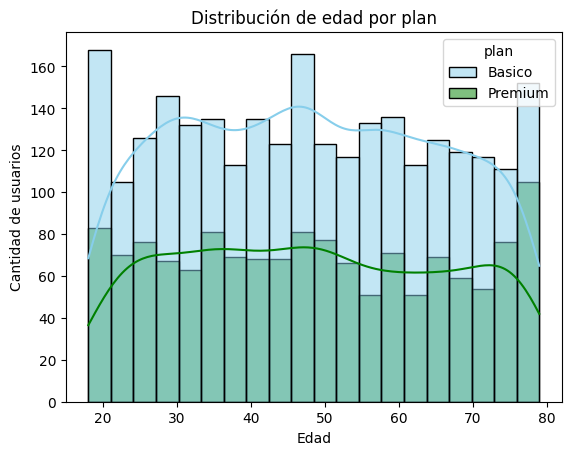

In [83]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age',hue='plan',palette=['skyblue','green'],bins=20,kde=True)
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- La distribución observada es multimodal ya que hay varios picos para el plan básico y premium. También observamos que la gente que más planes básicos compra son las de 20 años, 48 y 78 años mientras que el premium son las de 78 años.

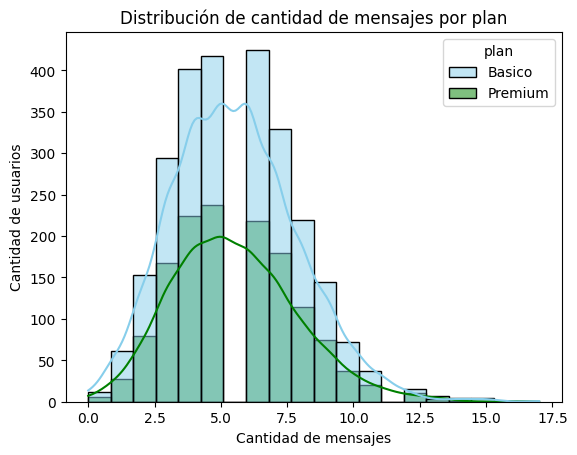

In [84]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes',hue='plan',palette=['skyblue','green'],bins=20,kde=True)
plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Ambas distribuciones parecerían siméricas pero tienen un ligero sesgo a la derecha. Por otro lado encontramos que hay más personas (mayor a 400) que envián entre 4 y 6.5 mensajes dentro del plan básico mientras que en el premium es parecido pero la cantidad de usuarios con plan premium es menor (alrededor de los 230 usuarios). También se observa un rango en el cual no se registra cierta cantidad de mensajes (entre el 5.2 y 6).

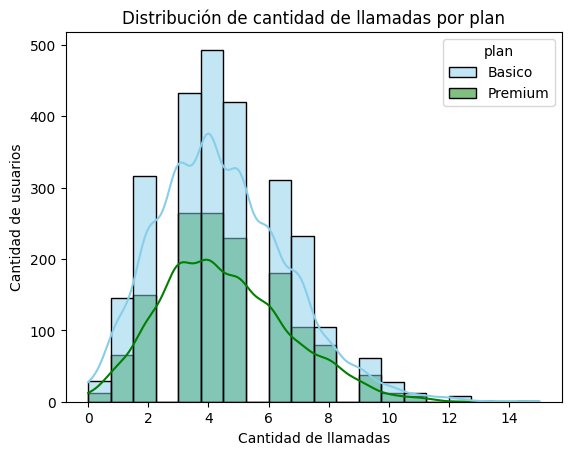

In [85]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas',hue='plan',palette=['skyblue','green'],bins=20,kde=True)
plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- Ambas distribuciones parecerían siméricas pero tienen un ligero sesgo a la derecha. Por otro lado encontramos que hay más personas (casi los 500) que llaman 4 veces dentro del plan básico mientras que en el premium es parecido pero la cantidad de usuarios con plan premium es menor (alrededor de los 250-260 usuarios). También se observa un rango en el cual no se registra cierta cantidad de llamadas (entre el 2.2 y 3,5.3 y 6 y 8.2 y 9).

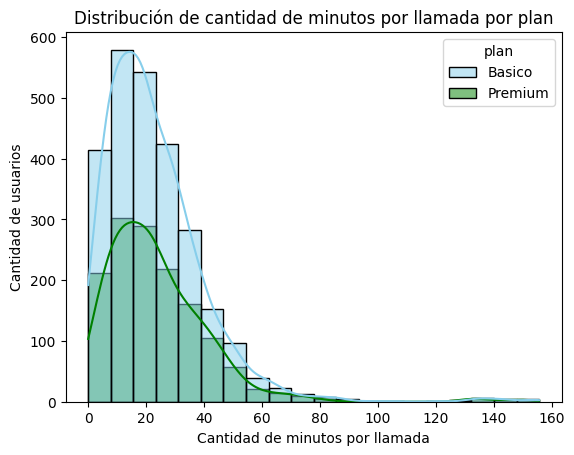

In [86]:

# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada',hue='plan',palette=['skyblue','green'],bins=20,kde=True)
plt.title('Distribución de cantidad de minutos por llamada por plan')
plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- La distribución para ambos planes está claramente con sesgo hacia la derecha. La cantidad de usuarios del básico ronda casi los 600 con una duración de 11 min por llamadas mientras que el plan premium tiene alrededor de 300 usuarios que hacen llamadas de 11 min también. Podemos ver que hay usuarios atípicos que aprovechan los minutos de su plan y tardan alrededor de 150 min por llamada.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

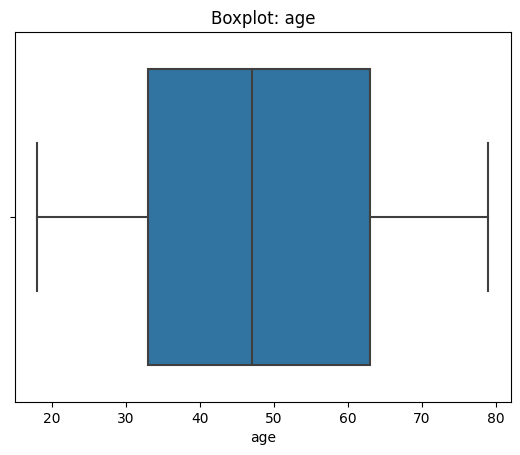

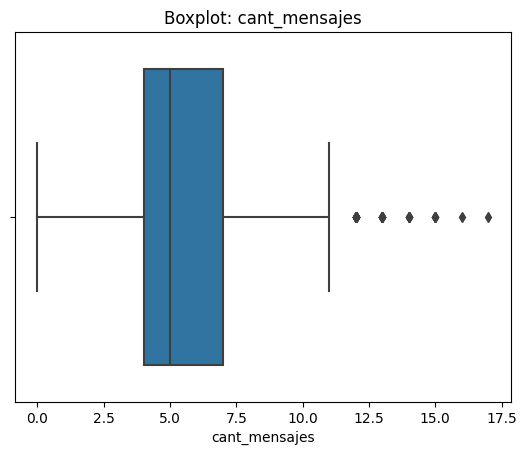

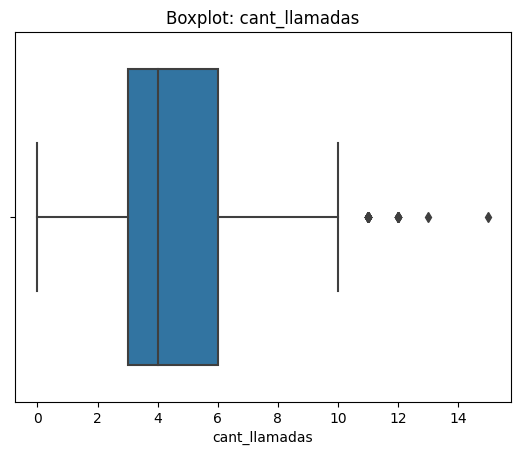

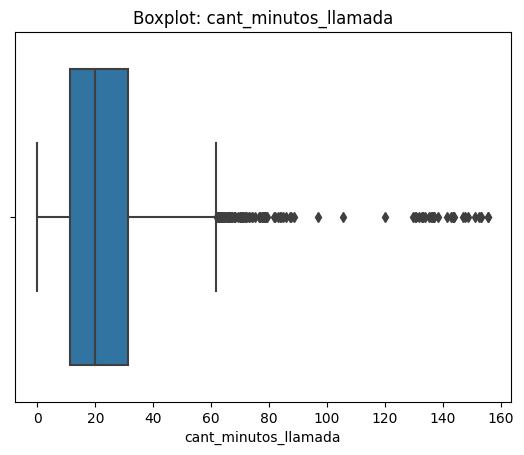

In [87]:
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile,x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
- Age: El boxplot de edad no presenta outliers y además tiene una distribución normal ya que la mediana está casi en el centro entre el Q1 y Q3)
- cant_mensajes: El boxplot de cant_mensajes sí presenta outliers de hasta 17 mensajes lo cual es atípico pero puede ser y además tiene una distribución con sesgo a la derecha ya que la mediana se encuentra pegada (más cerca) al Q1.
- cant_llamadas: El boxplot de cant_llamadas sí presenta outliers de hasta 15 llamadas lo cual es atípico pero puede ser y además tiene una distribución con sesgo a la derecha ya que la mediana se encuentra pegada (más cerca) al Q1.
- cant_minutos_llamada: El boxplot de cant_minutos_llamada sí presenta outliers de hasta casi los 160min por llamada lo cual es atípico pero puede ser y además tiene una distribución con ligero sesgo a la derecha ya que la mediana se encuentra pegada (más cerca) al Q1.

In [88]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
for col in columnas_limites:
    q1=user_profile[col].quantile(0.25)
    q3=user_profile[col].quantile(0.75)
    IQR=q3-q1
    upper=q3+1.5*IQR
    print(f'{col}: upper= {upper:.2f}')


cant_mensajes: upper= 11.50
cant_llamadas: upper= 10.50
cant_minutos_llamada: upper= 61.86


In [89]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener 
- cant_llamadas: mantener 
- cant_minutos_llamada: mantener
**¿POR QUÉ?**
  Decidí mantener los outliers ya que, en el contexto de telecomunicaciones, es posible que ciertos usuarios como vendedores o empresas de telemarketing tengan un uso significativamente mayor al promedio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [96]:


# Crear columna grupo_uso

def grupo_uso(row):
    mensajes=row['cant_mensajes']
    llamadas=row['cant_llamadas']
    if llamadas<5 and mensajes<5:
        return 'Bajo uso'
    if llamadas<10 and mensajes<10:
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile['grupo_uso']=user_profile.apply(grupo_uso,axis=1)



    

In [97]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [98]:
# Crear columna grupo_edad
def grupo_edad(row):
    age=row['age']
    if age<30:
        return 'Joven'
    if age<60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile['grupo_edad']=user_profile.apply(grupo_edad,axis=1)

In [99]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

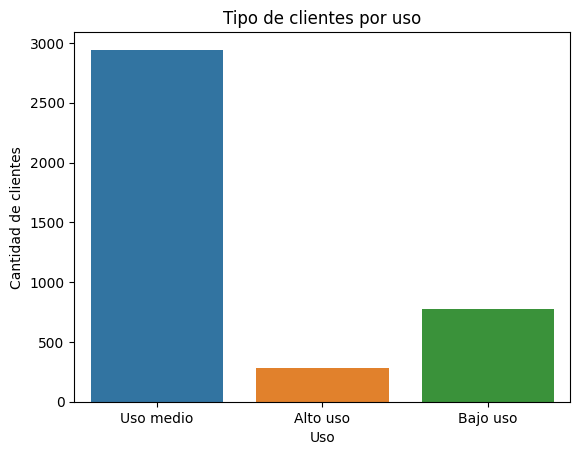

In [101]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile,x='grupo_uso')
plt.title('Tipo de clientes por uso')
plt.xlabel('Uso')
plt.ylabel('Cantidad de clientes')
plt.show()


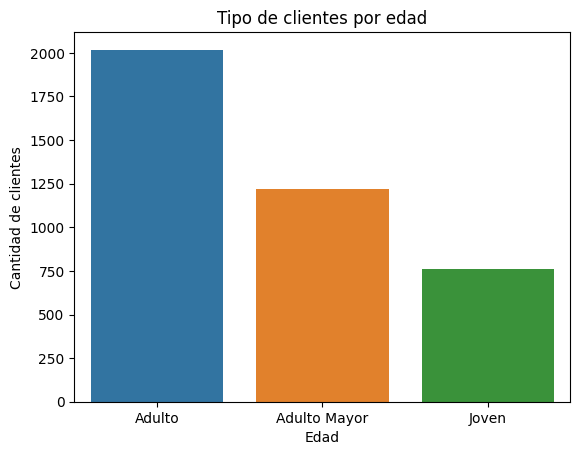

In [102]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x='grupo_edad')
plt.title('Tipo de clientes por edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad de clientes')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


Habían datos inválidos, sentinels que habían que imputar ya que el dejarlos modificaba nuestro promedio para las medidas estadísticas.
En la tabla de users se encontraron valores nulos en las columnas city (469) en proporción 11.73% y en churn_date(3534) en proporción 88.35%. Por otro lado, en la tabla de usage se observaron valores nulos en las columnas date(50) en porporción 0.13%, duration(22076) en porporción 55% y lenght(17896) en porporción 44.7%


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se identificaron dos segmentos de clientes: por uso (llamadas, mensajes) y por edad. Conforme a lo graficado se obtuvo que la mayoría de los usuarios le da un uso medio a su teléfono, es decir, realiza más de 5 llamadas y mensajes pero menos de 10 llamadas y mensajes. Después le sigue un uso bajo y al final un uso alto que posiblemente se trate de las personas que se dedican a vender o empresas de telemarketing.
Conforme a la edad, observmos que la mayoría de las personas que usan los servicios ofrecidos por la empresa ConnectaTel son adultos (mayores de 30 y menores de 60), seguido por los adultos de mayor edad (>60) y por último los jóvenes (<30).  
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Los segmentos más valiosos para ConnectaTel son los Adultos con un uso Medio porque son los que se presentan en mayor cantidad en relación a su respectivas categorías.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Se encontraron outliers para la cantidad de mensajes, llamadas y cantidad de minutos por llamadas los cuales pueden presentar una oportunidad de ofrecer un plan específico para aquellas personas si es que la hipótesis de que la fuente son empresas de ventas o telemarketing es correcta.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
1) Si mis outliers son provenientes de empresas de ventas o telemarketing, recomiendo armar un plan específico para ellos.
2) Invertir específicamente en el rango de Adultos (entre 30 y 60 años de edad) que son los que más aporte económico representan, ofreciendo el plan básico que representa un (64.87% del total de usuarios;2595 usuarios).
3) Sin embargo, los usuarios del plan premium no pueden descartarse, descuidarse, debido a que representan un 35.12% del total de usuarios (1405 usuarios) los cuales aportan incluso una cifra económica (ganancias) superior a los usuarios del plan básico:
**Básico**-> 12USD/mes X 2595 usuarios= **31140 USD/mes**.
**Premium**-> 25USD/mes x 1405 usuarios= **35125 USD/mes**.
Se sugiere mantener la calidad de atención para usuarios premium o investigar qué más se les puede ofrecer que sea de valor/utilidad para ellos. Ej. Facilidad de pagos, acceso a opciones especiales en una plataforma vip de ConnectaTel, antención especial (menor tiempo de respuesta), etc.



✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Habían datos inválidos, sentinels que habían que imputar ya que el dejarlos modificaba nuestro promedio para las medidas estadísticas.
En la tabla de users se encontraron valores nulos en las columnas city (469) en proporción 11.73% y en churn_date(3534) en proporción 88.35%. Por otro lado, en la tabla de usage se observaron valores nulos en las columnas date(50) en porporción 0.13%, duration(22076) en porporción 55% y lenght(17896) en porporción 44.7%

🔍 **Segmentos por Edad**
Conforme a la edad, observmos que la mayoría de las personas que usan los servicios ofrecidos por la empresa ConnectaTel son adultos (mayores de 30 y menores de 60), seguido por los adultos de mayor edad (>60) y por último los jóvenes (<30).  

📊 **Segmentos por Nivel de Uso**
Se identificaron dos segmentos de clientes: por uso (llamadas, mensajes) y por edad. Conforme a lo graficado se obtuvo que la mayoría de los usuarios le da un uso medio a su teléfono, es decir, realiza más de 5 llamadas y mensajes pero menos de 10 llamadas y mensajes. Después le sigue un uso bajo y al final un uso alto que posiblemente se trate de las personas que se dedican a vender o empresas de telemarketing.

➡️ Esto sugiere que ...
Los segmentos más valiosos para ConnectaTel son los Adultos con un uso Medio porque son los que se presentan en mayor cantidad en relación a su respectivas categorías.

💡 **Recomendaciones**
1) Si mis outliers son provenientes de empresas de ventas o telemarketing, recomiendo armar un plan específico para ellos.
2) Invertir específicamente en el rango de Adultos (entre 30 y 60 años de edad) que son los que más aporte económico representan, ofreciendo el plan básico que representa un (64.87% del total de usuarios;2595 usuarios).
3) Sin embargo, los usuarios del plan premium no pueden descartarse, descuidarse, debido a que representan un 35.12% del total de usuarios (1405 usuarios) los cuales aportan incluso una cifra económica (ganancias) superior a los usuarios del plan básico:
**Básico**-> 12USD/mes X 2595 usuarios= **31140 USD/mes**.
**Premium**-> 25USD/mes x 1405 usuarios= **35125 USD/mes**.
Se sugiere mantener la calidad de atención para usuarios premium o investigar qué más se les puede ofrecer que sea de valor/utilidad para ellos. Ej. Facilidad de pagos, acceso a opciones especiales en una plataforma vip de ConnectaTel, antención especial (menor tiempo de respuesta), etc.
 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`